# Record repair and openness evidence pool (iteration 5, evaluation 4)

This notebook is a runnable walk-through of `eval.py`, the driver of the evaluation artifact **art_a43GbNXWVFaL**, part of the study *"Concepts spread once adopters make them"*. The study asks which temporal network indicators predict the emergence of scientific concepts, using OpenAlex.

The evaluation collected **no new data** and spent **$0 on LLM calls**. It did three things:

1. **Record repair.** It cleared 10 MUST-FIX items in the running research report and applied the corrections from an earlier evaluation (Eval3) to a copy of the report. It then re-verified the claims ledger: v3 has 1,290 rows and v4 has 1,769 rows, with 0 MISMATCH and 0 NOT_FOUND in both.
2. **Gates.** G0 checks that all 48 input files exist. G1 and G2 re-compute the published `OPEN_home` partial-Spearman values, and G3 re-runs the ledger verifier.
3. **Evidence synthesis.** The study scored `OPEN_home` (openness of a concept's home neighbourhood) and `NOVCHURN_home` in several data "bodies": the DEV selection set, four held-out field groups, the 2010-14 cohort and the 2015-17 cohort. Each cell is a rank-residual **partial Spearman (psp)** against the outcome `O2r_m50`. The cells are pooled with **DerSimonian-Laird on Fisher z**, and a **Hartung-Knapp-Sidik-Jonkman (HKSJ)** interval is also reported.

In the original, `eval.py` first runs six sub-scripts in `src/`: `synthesis.py`, `build_corrections.py`, `apply_corrections.py`, `refs.py`, `figures.py` and `checks.py`. These scripts need the whole multi-GB run tree. It then **assembles** their outputs into `eval_out.json`, which follows the `exp_eval_sol_out` schema.

This notebook runs the **assembly step** (`--assemble-only`) on the sub-script outputs, which are bundled in `mini_demo_data.json`. It also re-computes the DL/HKSJ pools from the per-body cells, using the `dl_hksj` function copied from `src/synthesis.py`, and redraws the evidence forest plot (`src/figures.py`).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports

This is the original import block of `eval.py`. `from paths import RES, jdump, rel, sha256` points at the run tree, so the notebook replaces it with inline copies of the helpers from `src/paths.py` (next cell). The notebook also imports `math`, `numpy` and `scipy.stats` for the pooling re-computation, and `matplotlib` for the figure.

In [2]:
from __future__ import annotations

import argparse
import csv
import json
import os
import subprocess
import sys
from pathlib import Path

sys.dont_write_bytecode = True

from loguru import logger

# --- extra imports for the notebook (pooling re-computation from src/synthesis.py + figure from src/figures.py)
import math
import numpy as np
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

## Data loading

`mini_demo_data.json` bundles, verbatim, every file that the assembly step of `eval.py` reads from `results/`:

| key | original file | content |
|---|---|---|
| `evidence_synthesis` | `results/evidence_synthesis.json` | 18 body x feature rows (psp at R0/R2/R3, bootstrap CI, `se_z`, placebo), the DL/HKSJ pools, and gates G1/G2 |
| `ledger_rerun` | `results/ledger_rerun.json` | ledger v3 and v4 re-verification, text presence, stale strings, verbatim checks |
| `corrections_applied` | `results/corrections_applied.csv` | 86 correction blocks and their status (APPLIED, ALREADY_PRESENT, ...) |
| `per_group_table` | `results/per_group_table.csv` | EXP8 held-out psp per indicator and field group |
| `refs_summary`, `not_found_notes`, `artifact_counts`, `inputs_manifest` | same names in `results/` | small side files |

The loader tries the GitHub copy first and falls back to a local file.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_AawnV1HvzpNx/round-5/evaluation-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({k: (len(v) if hasattr(v, "__len__") else v) for k, v in data.items() if k != "_about"})

{'evidence_synthesis': 6, 'ledger_rerun': 5, 'corrections_applied': 86, 'refs_summary': 9, 'per_group_table': 42, 'not_found_notes': 1, 'artifact_counts': 5, 'inputs_manifest': 3}


## Configuration

`eval.py` takes two command-line arguments. `--assemble-only` skips the six sub-scripts, and `--nboot` sets the number of concept-bootstrap draws in `src/synthesis.py` (2000 in the original).

This notebook only assembles: the sub-scripts need the full run tree (parquet frames and earlier artifacts), so `ASSEMBLE_ONLY = True` and `NBOOT` has no effect here. The whole notebook runs in seconds, so the other settings are already at the original values. They are the number of examples per dataset in the mini output (3) and the string length in the preview output (200).

In [5]:
ASSEMBLE_ONLY = True        # original default False; the sub-scripts need the full run tree, so the demo only assembles
NBOOT = "2000"              # bootstrap draws for src/synthesis.py (original 2000; only used when ASSEMBLE_ONLY = False)
N_MINI_EXAMPLES = 3         # examples per dataset in mini_eval_out.json (original 3)
PREVIEW_TRUNC = 200         # max string length in preview_eval_out.json (original 200)
WS = Path("demo_outputs")   # where eval_out.json & co. are written (original: the artifact folder)

## Setup: helpers from `src/paths.py` and logging

The original reads files from `RES = WS / "results"`. In the notebook, `RES` is a small in-memory lookup built from `data`, so `json.loads((RES / "x.json").read_text())` becomes `RES["x.json"]`. `_clean`, `jdump`, `sha256` and `rel` are copied from `src/paths.py`. The logger set-up is unchanged: stdout plus a rotating file sink.

In [6]:
WS.mkdir(parents=True, exist_ok=True)
(WS / "logs").mkdir(exist_ok=True)

# in-memory stand-in for the results/ folder (file name -> parsed content, CSVs as lists of string-valued dicts)
RES = {"evidence_synthesis.json": data["evidence_synthesis"], "ledger_rerun.json": data["ledger_rerun"],
       "corrections_applied.csv": data["corrections_applied"], "refs_summary.json": data["refs_summary"],
       "per_group_table.csv": data["per_group_table"], "not_found_notes.json": data["not_found_notes"],
       "artifact_counts.json": data["artifact_counts"], "inputs_manifest.json": data["inputs_manifest"]}


# --- copied from src/paths.py
def _clean(o):
    if isinstance(o, dict):
        return {str(k): _clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_clean(v) for v in o]
    if isinstance(o, (np.floating, float)):
        return None if not math.isfinite(float(o)) else float(o)
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.bool_):
        return bool(o)
    return o


def jdump(p: Path, obj) -> None:
    Path(p).write_text(json.dumps(_clean(obj), indent=1))


def sha256(p: Path) -> str:
    import hashlib
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for b in iter(lambda: f.read(1 << 20), b""):
            h.update(b)
    return h.hexdigest()


def rel(p: Path) -> str:
    return str(Path(p))


logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(WS / "logs/eval.log", rotation="30 MB", level="DEBUG")

2

## Sub-script runner and input manifest

`run()` is the original function: it runs one `src/*.py` step with single-threaded BLAS and keeps its stdout in `logs/`. The notebook only calls it when `ASSEMBLE_ONLY = False`.

In the original, `inputs_manifest()` hashes the 48 read-only inputs, such as the iteration-4 and iteration-5 reports, the Exp8/Exp10/Exp11/Exp12 results, the Eval3 ledger and the research artifacts. Those files are not available here, so the notebook uses the manifest `eval.py` recorded (`results/inputs_manifest.json`, with sha256, size and mtime for each file). Gate G0 reads its `all_exist` flag.

In [7]:
def run(script: str, *args: str) -> None:
    env = dict(os.environ, PYTHONDONTWRITEBYTECODE="1", OMP_NUM_THREADS="1", OPENBLAS_NUM_THREADS="1",
               MKL_NUM_THREADS="1")
    logger.info(f"running {script} {' '.join(args)}")
    r = subprocess.run([sys.executable, str(WS / script), *args], env=env, capture_output=True, text=True)
    (WS / "logs" / f"{Path(script).stem}_stdout.log").write_text(r.stdout + r.stderr)
    if r.returncode:
        raise RuntimeError(f"{script} failed:\n{r.stderr[-1500:]}")


def inputs_manifest() -> dict:
    # original: sha256/bytes/mtime of the 48 run-tree inputs (REPORT5, REPORT4, Eval3 verifier + ledger v3, Exp12
    # case_pairs / prereg / decomposition / trajectories / atlas, Exp10 cohort + frozen_spec + parquet frames + lib/,
    # Exp11 prereg / FE results / logs, Exp8 held-out results + outcomes.parquet, Exp7 step2, Exp5 frame, R1-R3 research).
    # notebook: the manifest eval.py recorded when those files were present
    return RES["inputs_manifest.json"]


def fmt_ci(c):
    return f"[{c[0]:+.3f}, {c[1]:+.3f}]"

## Step 1: arguments, gate G0 and the (skipped) pipeline

The original body of `main()` begins here. The notebook runs it at top level, one cell per section. The notebook passes the config values to `parse_args` instead of the command line.

In [8]:
ap = argparse.ArgumentParser()
ap.add_argument("--assemble-only", action="store_true")
ap.add_argument("--nboot", default="2000")
a = ap.parse_args((["--assemble-only"] if ASSEMBLE_ONLY else []) + ["--nboot", NBOOT])
man = inputs_manifest()
jdump(WS / "inputs_manifest.json", man)
if not man["all_exist"]:
    raise FileNotFoundError([f["path"] for f in man["files"] if not f["exists"]])
if not a.assemble_only:
    run("src/synthesis.py", "--nboot", a.nboot, "--nperm", "200", "--workers", "3")
    run("src/build_corrections.py")
    run("src/apply_corrections.py")
    run("src/refs.py")
    run("src/figures.py")
    run("src/checks.py")
print(f"G0: {man['n']} inputs recorded, all_exist={man['all_exist']}; assemble_only={a.assemble_only}")

G0: 48 inputs recorded, all_exist=True; assemble_only=True


## Step 2: read the sub-script outputs and evaluate gates G1-G3

- **G1** re-computes Exp10's EXP5 `OPEN_home` psp at R0 (+0.099) and R2 (+0.076) and requires a match to 3 decimal places.
- **G2** re-computes the 2010-14 cohort `OPEN_home` R2 = +0.091 [+0.013, +0.171] with Exp10's bootstrap seed, and also with seed 0.
- **G3** requires the copied Eval3 verifier to reproduce ledger v3 exactly: 1,290 rows, 0 MISMATCH, 0 NOT_FOUND and 9 orphan numeric tokens.

In [9]:
syn = RES["evidence_synthesis.json"]
chk = RES["ledger_rerun.json"]
app = RES["corrections_applied.csv"]
refs = RES["refs_summary.json"]
g1, g2 = syn["gates"]["G1"], syn["gates"]["G2"]
v3, v4 = chk["a_v3_reverify"], chk["b_v4"]
g3 = (v3["n_rows"] == 1290 and v3["n_mismatch_recomputed"] == 0 and v3["n_not_found_recomputed"] == 0
      and v3["n_orphan_numeric_tokens"] == 9)
gates = {"G0_inputs_exist": man["all_exist"], "G1_R0": g1["pass_R0"], "G1_R2": g1["pass_R2"], "G2": g2["pass"],
         "G3": g3}
jdump(WS / "gates.json", {"gates": gates, "G1": g1, "G2": {k: v for k, v in g2.items()},
                          "G3": {k: v3[k] for k in ("n_rows", "recomputed_status_counts", "n_mismatch_recomputed",
                                                    "n_not_found_recomputed", "n_orphan_numeric_tokens")}})
print(gates)

{'G0_inputs_exist': True, 'G1_R0': True, 'G1_R2': True, 'G2': True, 'G3': True}


## Step 3: the 10 MUST-FIX items

Each MUST-FIX item is cleared only if all of the following hold:

- Its correction blocks (from `corrections_iter5/NN_*.md`) have status `APPLIED` in `corrections_applied.csv`.
- Where the item requires them, the byte-exact verbatim checks pass, for example the preregistrations PR1-PR3 and Section 23.
- No stale strings remain, for example the invented Section 26.4 case rows.

In [10]:
st = {}
for r in app:
    st[r["status"]] = st.get(r["status"], 0) + 1
by = {(r["source_file"], r["block_id"]): r["status"] for r in app}

def ok(fn, *bids):
    return all(by.get((fn, b)) == "APPLIED" for b in bids)

verb = chk["e_verbatim"]
stale = chk["d_stale"]
eval3_missing = sum(1 for r in app if r["status"] == "NOT_APPLIED_TARGET_MISSING")
mustfix = {
    "1_case_studies_26_4": ok("01_case_studies_26_4.md", "26.4_rebuilt", "26.5_atlas") and stale["n_stale_hits"] == 0,
    "2_exp11_25a": ok("02_exp11_25a.md", "25a_exp11", "29_deadend_exp11", "28.1_c4", "24_counts", "31_counts")
    and verb["Exp11_HM1_HP1_lines_24_32_verbatim"],
    "3_exp10_rewrite": ok("03_exp10_rewrite.md", "25.1", "25.2", "25.4", "25.7", "25.8", "31.1"),
    "4_exp12_rewrite": ok("04_exp12_rewrite.md", "26.1", "26.3", "26.2_pc", "31.3_caveat")
    and all(verb[f"{k}_verbatim"] for k in ("PR1", "PR1b", "PR2", "PR3")),
    "5_eval3_application": eval3_missing == 0 and ok("05_eval3_application.md", "27.6_list"),
    "6_section23_restore": ok("06_section23_restore.md", "23_restore", "16.2_tag") and verb["section23_byte_identical"],
    "7_section28_evidence": ok("07_section28_evidence.md", "28.1_evidence", "28.2_survives", "31.2_retention"),
    "8_secondary": ok("08_exp8_exp10_secondary.md", "25.5_leads", "25.6", "19.5b_tag", "19.7_tag", "19.2_pergroup")
    and verb["Exp10_leads_block_lines_48_53_verbatim"],
    "9_coverage_table_30": ok("09_coverage_table_30.md", "30_table"),
    "10_minor_and_refs": ok("10_minor_and_refs.md", "fcr", "27.3_I2", "27.2_label") and stale["n_stale_hits"] == 0
    and refs["n_master"] > 0}
print("correction status counts:", st)
for k, v in mustfix.items():
    print(f"  {k:<24} {'CLEARED' if v else 'OPEN'}")

correction status counts: {'ALREADY_PRESENT': 5, 'APPLIED': 76, 'NOT_APPLIED_SUPERSEDED': 5}
  1_case_studies_26_4      CLEARED
  2_exp11_25a              CLEARED
  3_exp10_rewrite          CLEARED
  4_exp12_rewrite          CLEARED
  5_eval3_application      CLEARED
  6_section23_restore      CLEARED
  7_section28_evidence     CLEARED
  8_secondary              CLEARED
  9_coverage_table_30      CLEARED
  10_minor_and_refs        CLEARED


## Step 4: aggregate metrics

This step builds the flat `metrics_agg` dictionary from:

- the ledger counts, the text-presence and stale-string checks, and the gate flags;
- the R2 psp for each body (DEV, the four held-out groups and the two cohorts);
- for each feature x rung, the **non-selection pool**: estimate, DL and HKSJ intervals, I², τ² on the z scale, k, sign agreement, and the shrinkage ratio of the DEV estimate over the pooled estimate.

In [11]:
rows = {(r["body"], r["feature"]): r for r in syn["rows"]}
m = {"n_mustfix_cleared": sum(mustfix.values()), "n_mustfix_total": len(mustfix),
     "ledger_v3_rows": v3["n_rows"], "ledger_v3_mismatch": v3["n_mismatch_recomputed"],
     "ledger_v3_not_found": v3["n_not_found_recomputed"], "ledger_v3_orphans": v3["n_orphan_numeric_tokens"],
     "ledger_v4_rows": v4["n_rows"], "ledger_v4_mismatch": v4["n_mismatch_recomputed"],
     "ledger_v4_not_found": v4["n_not_found_recomputed"], "ledger_v4_orphans": v4["n_orphan_numeric_tokens"],
     "ledger_v4_disagreements": v4["n_disagreements"],
     "text_present_v3": chk["c_text_presence"]["v3"]["counts"].get("TEXT_PRESENT", 0),
     "text_present_elsewhere_v3": chk["c_text_presence"]["v3"]["counts"].get("TEXT_PRESENT_ELSEWHERE", 0),
     "text_absent_v3": chk["c_text_presence"]["v3"]["counts"].get("TEXT_ABSENT", 0),
     "text_present_v4": chk["c_text_presence"]["v4"]["counts"].get("TEXT_PRESENT", 0),
     "text_absent_v4": chk["c_text_presence"]["v4"]["counts"].get("TEXT_ABSENT", 0)
     + chk["c_text_presence"]["v4"]["counts"].get("TEXT_PRESENT_ELSEWHERE", 0),
     "stale_hits": stale["n_stale_hits"], "stale_correction_note_mentions": stale["n_correction_note_mentions"],
     "verbatim_checks_passed": sum(verb.values()), "verbatim_checks_total": len(verb),
     "gate_G0_pass": int(gates["G0_inputs_exist"]), "gate_G1_R0_pass": int(gates["G1_R0"]),
     "gate_G1_R2_pass": int(gates["G1_R2"]), "gate_G2_pass": int(gates["G2"]), "gate_G3_pass": int(gates["G3"]),
     "G1_open_home_R0_recomputed": g1["OPEN_home|O2r_m50|R0"]["recomputed"],
     "G1_open_home_R2_recomputed": g1["OPEN_home|O2r_m50|R2"]["recomputed"],
     "G2_cohort_open_home_R2": g2["R2"]["rho"], "G2_cohort_open_home_R3": g2["R3"]["rho"],
     "corrections_applied": st.get("APPLIED", 0), "corrections_already_present": st.get("ALREADY_PRESENT", 0),
     "corrections_not_applied_target_missing": st.get("NOT_APPLIED_TARGET_MISSING", 0),
     "corrections_not_applied_superseded": st.get("NOT_APPLIED_SUPERSEDED", 0),
     "references_master_n": refs["n_master"], "references_cited_n": refs["n_cited"],
     "references_excluded_unverified_n": refs["n_excluded"]}
short = {"B1_DEV": "B1_dev", "B2_HELDOUT_pooled": "B2_heldout_pooled", "B3_EXP5_COHORT_2010_14": "B3_cohort1014",
         "B4_COHORT_2015_17": "B4_cohort1517", "B2_PHYS": "B2_phys", "B2_LIFEENV": "B2_lifeenv", "B2_SOC": "B2_soc",
         "B2_MATHDEC": "B2_mathdec"}
for (b, f), r in rows.items():
    if b in short and r["R2"]["psp"] is not None:
        m[f"psp_R2_{f}_{short[b]}"] = r["R2"]["psp"]
for f in ("OPEN_home", "NOVCHURN_home"):
    for rung in ("R0", "R2", "R3"):
        p = syn["pools"][f"{f}|{rung}"]
        n = p["nonselection"]
        tag = f"{f}_{rung}"
        m[f"pooled_nonselection_{tag}"] = n["est"]
        m[f"pooled_nonselection_{tag}_dl_lo"], m[f"pooled_nonselection_{tag}_dl_hi"] = n["dl_ci"]
        m[f"pooled_nonselection_{tag}_hksj_lo"], m[f"pooled_nonselection_{tag}_hksj_hi"] = n["hksj_ci"]
        m[f"pooled_nonselection_{tag}_I2"] = n["I2"]
        m[f"pooled_nonselection_{tag}_tau2_z"] = n["tau2_z"]
        m[f"pooled_nonselection_{tag}_k"] = n["k"]
        m[f"pooled_all_bodies_{tag}"] = p["all_bodies_includes_selection_data"]["est"]
        m[f"shrinkage_selection_over_nonselection_{tag}"] = p["shrinkage_ratio_selection_over_nonselection"]
        k_pos, k_all = p["sign_agreement_nonselection"].split("/")
        m[f"sign_agreement_nonselection_{tag}_pos"] = int(k_pos)
        m[f"sign_agreement_nonselection_{tag}_k"] = int(k_all)
print(f"{len(m)} metrics")

124 metrics


## Step 5: per-example datasets

This step builds the three `exp_eval_sol_out` datasets:

- `evidence_synthesis`: one example per body x feature x rung. Each example carries its psp, bootstrap CI, n, design status and, at R2, the 95th percentile of |psp| under within-body outcome permutation (the placebo).
- `per_group_table_exp8_O2r_m50`: EXP8 held-out psp for each indicator x field group, with a flag for whether the CI includes 0.
- `corrections_applied`: one example per correction block and its application status.

In [12]:
ds_syn = []
for r in syn["rows"]:
    for rung in ("R0", "R2", "R3"):
        if rung not in r:
            continue
        c = r[rung]
        ds_syn.append({"input": f"body={r['body']} | feature={r['feature']} | outcome=O2r_m50 | rung={rung} | "
                                f"status={r['status']}",
                       "output": ("pending iteration-5 artifact" if c["psp"] is None else
                                  f"psp {c['psp']:+.3f} {fmt_ci(c['ci'])} n={c['n']}"),
                       "metadata_body": r["body"], "metadata_feature": r["feature"], "metadata_rung": rung,
                       "metadata_status": r["status"], "metadata_n": c.get("n"),
                       **({"eval_psp": c["psp"], "eval_ci_lo": c["ci"][0], "eval_ci_hi": c["ci"][1]}
                          if c["psp"] is not None else {}),
                       **({"eval_placebo_p95_abs_psp": r["placebo"]["p95_abs_psp"]}
                          if "placebo" in r and rung == "R2" else {})})
pg = RES["per_group_table.csv"]
ds_pg = [{"input": f"indicator={r['indicator']} | unit={r['unit']} | outcome=O2r_m50 (EXP8 held-out)",
          "output": f"psp {float(r['psp']):+.3f} [{float(r['ci_lo']):+.3f}, {float(r['ci_hi']):+.3f}] "
                    f"n={r['n']}{' (CI includes 0)' if r['ci_includes_0'] == 'True' else ''}",
          "metadata_indicator": r["indicator"], "metadata_unit": r["unit"],
          "eval_psp": float(r["psp"]), "eval_ci_lo": float(r["ci_lo"]), "eval_ci_hi": float(r["ci_hi"]),
          "eval_n": int(r["n"]), "eval_ci_includes_0": int(r["ci_includes_0"] == "True")} for r in pg]
ds_app = [{"input": f"{r['source_file']} :: {r['block_id']} -> {r['target_section']} ({r['action']})",
           "output": f"{r['status']}: {r['reason']}", "metadata_source_file": r["source_file"],
           "metadata_status": r["status"],
           "eval_applied": int(r["status"] == "APPLIED"),
           "eval_line_in_corrected": int(r["line_in_corrected_final"])} for r in app]
print(len(ds_syn), len(ds_pg), len(ds_app))
for e in ds_syn[:4]:
    print(e["input"], "->", e["output"])

50 42 86
body=B1_DEV | feature=OPEN_home | outcome=O2r_m50 | rung=R0 | status=selection -> psp +0.139 [+0.103, +0.174] n=3003
body=B1_DEV | feature=OPEN_home | outcome=O2r_m50 | rung=R2 | status=selection -> psp +0.109 [+0.073, +0.144] n=3003
body=B1_DEV | feature=OPEN_home | outcome=O2r_m50 | rung=R3 | status=selection -> psp +0.084 [+0.048, +0.121] n=3003
body=B1_DEV | feature=NOVCHURN_home | outcome=O2r_m50 | rung=R0 | status=selection -> psp +0.125 [+0.088, +0.162] n=2741


## Step 6: write `eval_out.json` and its full, mini and preview variants

The metadata records what the evaluation does **not** claim: the pooled estimate is descriptive and uses bodies whose outcomes were already read. It also lists every deviation from the plan. The file is written in the `exp_eval_sol_out` layout.

In [13]:
out = {"metadata": {
    "evaluation_name": "Fix the record and pool the openness evidence (iteration 5, evaluation 4)",
    "plan": "3_invention_loop/iter_5/gen_plan/gen_plan_evaluation_1",
    "llm_spend_usd": 0.0, "openalex_credit": 0, "new_data": False, "unseal": False,
    "mustfix": mustfix, "gates": gates,
    "estimator": syn["design"]["estimator"], "synthesis_design": syn["design"],
    "status_labels": {"selection": "data on which the index / constants were chosen",
                      "already-unsealed": "held-out data whose outcomes earlier artifacts had read",
                      "confirmatory": "never used before the test",
                      "pending iteration-5 artifact": "Frame N slot, empty"},
    "not_claimed": ["no new confirmation: the pooled estimate is descriptive and uses already-unsealed bodies",
                    "NOVCHURN_home on the 2015-17 cohort is a selection estimate",
                    "the ledger checks numbers against files, not the reasoning around them"],
    "not_found_notes": RES["not_found_notes.json"],
    "deviations": [
        "bootstrap seed = Exp10's frozen 20260929 (plan said 0) so every CI is comparable with the record; G2 was "
        "also run with seed 0 (CI within +-0.005, reported in results/gates_g1_g2.json)",
        "DL pooling on Fisher z (plan) whereas Exp10 pooled raw psp; reported values are back-transformed",
        "the 37-concept AI atlas is atlas.json -> concepts (ai_atlas/table.csv is the per-measure median table)",
        "the OPEN~PC1/PC2 table is read from trajectories_dev/heldout.json (open_diagnostics.json has no PC table)",
        "reference de-duplication uses first-author surname + year + first 5 words of the title head (before "
        "':' or '?') and a prefix pass, because the end-of-report list abbreviates titles",
        "Eval3 blocks already present with >= 90% of their numbers are marked ALREADY_PRESENT; partial ones are "
        "appended in full with a note",
        "the review's 'Exp8 raw sign flip +0.143 / -0.126' is not in any file (NOT_FOUND) and is not used"],
    "artifact_counts": RES["artifact_counts.json"],
    "references": refs},
    "metrics_agg": {k: float(v) for k, v in m.items() if v is not None},
    "datasets": [{"dataset": "evidence_synthesis", "examples": ds_syn},
                 {"dataset": "per_group_table_exp8_O2r_m50", "examples": ds_pg},
                 {"dataset": "corrections_applied", "examples": ds_app}]}
jdump(WS / "eval_out.json", out)
jdump(WS / "full_eval_out.json", out)
mini = dict(out, datasets=[dict(d, examples=d["examples"][:N_MINI_EXAMPLES]) for d in out["datasets"]])
jdump(WS / "mini_eval_out.json", mini)

def trunc(o):
    if isinstance(o, str):
        return o[:PREVIEW_TRUNC]
    if isinstance(o, list):
        return [trunc(x) for x in o]
    if isinstance(o, dict):
        return {k: trunc(v) for k, v in o.items()}
    return o
jdump(WS / "preview_eval_out.json", trunc(mini))
logger.info(f"must-fix cleared {m['n_mustfix_cleared']}/10: {mustfix}")
logger.info(f"gates {gates}; metrics {len(m)}")

11:44:50|INFO   |must-fix cleared 10/10: {'1_case_studies_26_4': True, '2_exp11_25a': True, '3_exp10_rewrite': True, '4_exp12_rewrite': True, '5_eval3_application': True, '6_section23_restore': True, '7_section28_evidence': True, '8_secondary': True, '9_coverage_table_30': True, '10_minor_and_refs': True}


11:44:50|INFO   |gates {'G0_inputs_exist': True, 'G1_R0': True, 'G1_R2': True, 'G2': True, 'G3': True}; metrics 124


## Check: re-compute the pools from the per-body cells

`src/synthesis.py` pools the per-body psp values with `dl_hksj` (copied here verbatim):

- It transforms each psp to Fisher z, using the bootstrap SE of z (`se_z`).
- It estimates τ² with DerSimonian-Laird and forms the random-effects mean.
- It adds a Hartung-Knapp-Sidik-Jonkman interval with t(k-1) degrees of freedom.
- It back-transforms the results to the correlation scale.

The **non-selection** pool excludes the DEV body, on which the index constants were chosen. For `OPEN_home` it uses the four held-out groups plus both cohorts (k = 6). For `NOVCHURN_home` it drops the 2015-17 cohort, which was a selection body for that feature (k = 5). The cell also re-computes the leave-one-body-out estimates and the shrinkage ratio of DEV over the pool.

In [14]:
def dl_hksj(rows: list[dict]) -> dict:
    """DL random effects on Fisher z (se_z from the bootstrap) + HKSJ interval; back-transformed to r."""
    z = np.array([math.atanh(r["rho"]) for r in rows])
    se = np.array([r["se_z"] for r in rows])
    k = len(z)
    w = 1 / se**2
    zf = (w * z).sum() / w.sum()
    Q = float((w * (z - zf) ** 2).sum())
    Cc = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / Cc) if k > 1 else 0.0
    ws = 1 / (se**2 + tau2)
    mu = float((ws * z).sum() / ws.sum())
    se_dl = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    q = float((ws * (z - mu) ** 2).sum() / (k - 1)) if k > 1 else math.nan
    se_hk = math.sqrt(q / ws.sum()) if k > 1 else math.nan
    t = stats.t.ppf(0.975, k - 1) if k > 1 else math.nan
    th = math.tanh
    return {"k": k, "est": th(mu), "dl_ci": [th(mu - 1.96 * se_dl), th(mu + 1.96 * se_dl)],
            "hksj_ci": [th(mu - t * se_hk), th(mu + t * se_hk)] if k > 1 else [math.nan, math.nan],
            "Q": Q, "I2": float(I2), "tau2_z": float(tau2), "z": mu, "se_z_dl": se_dl, "se_z_hksj": se_hk,
            "I2_note": "imprecise at small k (k <= 6)"}


# res[body|feature|rung] -> {"rho", "se_z", "body"} rebuilt from the synthesis rows (same keys synthesis.py uses)
res = {f"{r['body']}|{r['feature']}|{rung}": {"rho": r[rung]["psp"], "se_z": r[rung]["se_z"]}
       for r in syn["rows"] if r["body"] != "B5_FRAME_N" for rung in ("R0", "R2", "R3")}
HELD = ["PHYS", "LIFEENV", "SOC", "MATHDEC"]
heldg = [f"B2_{g}" for g in HELD]

def cells(feature, keys, rung):
    return [dict(res[f"{k}|{feature}|{rung}"], body=k) for k in keys]

recomp = []
for rung in ("R0", "R2", "R3"):
    for f in ("OPEN_home", "NOVCHURN_home"):
        nonsel = heldg + ["B3_EXP5_COHORT_2010_14"] + (["B4_COHORT_2015_17"] if f == "OPEN_home" else [])
        cs = [c for c in cells(f, nonsel, rung) if np.isfinite(c["rho"]) and np.isfinite(c["se_z"])]
        p = dl_hksj(cs)
        loo = {c["body"]: dl_hksj([x for x in cs if x["body"] != c["body"]])["est"] for c in cs}
        stored = syn["pools"][f"{f}|{rung}"]
        recomp.append({"feature": f, "rung": rung, "k": p["k"], "est": p["est"], "dl_ci": p["dl_ci"],
                       "hksj_ci": p["hksj_ci"], "I2": p["I2"],
                       "shrinkage": res[f"B1_DEV|{f}|{rung}"]["rho"] / p["est"],
                       "loo_range": (min(loo.values()), max(loo.values())),
                       "max_abs_diff_vs_stored": max(abs(p["est"] - stored["nonselection"]["est"]),
                                                     *(abs(x - y) for x, y in zip(p["dl_ci"] + p["hksj_ci"],
                                                        stored["nonselection"]["dl_ci"] + stored["nonselection"]["hksj_ci"])))})

print(f"{'feature':<14}{'rung':<5}{'k':>2}  {'pool':>7}  {'DL 95% CI':<18}  {'HKSJ 95% CI':<18} {'I2':>5} {'DEV/pool':>8}  {'LOO range':<18} {'|diff|':>8}")
for r in recomp:
    print(f"{r['feature']:<14}{r['rung']:<5}{r['k']:>2}  {r['est']:+.3f}  {fmt_ci(r['dl_ci']):<18}  {fmt_ci(r['hksj_ci']):<18} "
          f"{r['I2']:5.2f} {r['shrinkage']:8.2f}  {fmt_ci(r['loo_range']):<18} {r['max_abs_diff_vs_stored']:.1e}")

feature       rung  k     pool  DL 95% CI           HKSJ 95% CI           I2 DEV/pool  LOO range            |diff|
OPEN_home     R0    6  +0.086  [+0.055, +0.116]    [+0.047, +0.124]    0.00     1.62  [+0.080, +0.093]   1.4e-17
NOVCHURN_home R0    5  +0.110  [+0.075, +0.146]    [+0.084, +0.137]    0.00     1.14  [+0.097, +0.116]   5.6e-17
OPEN_home     R2    6  +0.069  [+0.038, +0.100]    [+0.042, +0.096]    0.00     1.58  [+0.064, +0.073]   1.4e-17
NOVCHURN_home R2    5  +0.105  [+0.069, +0.140]    [+0.078, +0.131]    0.00     1.11  [+0.094, +0.110]   5.6e-17
OPEN_home     R3    6  +0.057  [+0.026, +0.088]    [+0.036, +0.078]    0.00     1.47  [+0.053, +0.061]   6.9e-18
NOVCHURN_home R3    5  +0.095  [+0.058, +0.131]    [+0.079, +0.111]    0.00     1.03  [+0.091, +0.098]   2.8e-17


## Results

The first table below lists the gates, the MUST-FIX status, the ledger checks and the headline pools. The forest plot after it (from `src/figures.py`) shows `OPEN_home` and `NOVCHURN_home` at R2 for each body. Its markers encode design status: grey filled means selection data, hollow blue means already-unsealed held-out data, and filled blue means confirmatory. The orange diamond is the non-selection DL pool; the thin line under it is the HKSJ interval. The dashed row is the empty Frame-N slot.

The pooled estimates are **descriptive**, because every non-selection body had already been read by earlier artifacts. The DEV estimate is larger than the pool, with a shrinkage ratio of about 1.6 for `OPEN_home`, which is the expected optimism of the selection data.

In [15]:
M = out["metrics_agg"]
summary = [
    ("MUST-FIX items cleared", f"{int(M['n_mustfix_cleared'])}/{int(M['n_mustfix_total'])}"),
    ("Gates G0 / G1-R0 / G1-R2 / G2 / G3", " / ".join("PASS" if v else "FAIL" for v in gates.values())),
    ("Ledger v3 rows / mismatch / not-found / orphans", f"{int(M['ledger_v3_rows'])} / {int(M['ledger_v3_mismatch'])} / {int(M['ledger_v3_not_found'])} / {int(M['ledger_v3_orphans'])}"),
    ("Ledger v4 rows / mismatch / not-found / orphans", f"{int(M['ledger_v4_rows'])} / {int(M['ledger_v4_mismatch'])} / {int(M['ledger_v4_not_found'])} / {int(M['ledger_v4_orphans'])}"),
    ("Verbatim checks passed", f"{int(M['verbatim_checks_passed'])}/{int(M['verbatim_checks_total'])}"),
    ("Corrections APPLIED / ALREADY_PRESENT / target missing", f"{int(M['corrections_applied'])} / {int(M['corrections_already_present'])} / {int(M['corrections_not_applied_target_missing'])}"),
    ("References in master list / excluded unverified", f"{int(M['references_master_n'])} / {int(M['references_excluded_unverified_n'])}"),
    ("G1 EXP5 OPEN_home psp R0 / R2", f"{M['G1_open_home_R0_recomputed']:+.3f} / {M['G1_open_home_R2_recomputed']:+.3f}"),
    ("G2 cohort 2010-14 OPEN_home R2 / R3", f"{M['G2_cohort_open_home_R2']:+.3f} / {M['G2_cohort_open_home_R3']:+.3f}"),
]
for f in ("OPEN_home", "NOVCHURN_home"):
    t = f"{f}_R2"
    summary.append((f"{f} R2 non-selection pool (k={int(M[f'pooled_nonselection_{t}_k'])})",
                    f"{M[f'pooled_nonselection_{t}']:+.3f} DL [{M[f'pooled_nonselection_{t}_dl_lo']:+.3f}, {M[f'pooled_nonselection_{t}_dl_hi']:+.3f}] "
                    f"HKSJ [{M[f'pooled_nonselection_{t}_hksj_lo']:+.3f}, {M[f'pooled_nonselection_{t}_hksj_hi']:+.3f}] "
                    f"I2 {M[f'pooled_nonselection_{t}_I2']:.2f}, {int(M[f'sign_agreement_nonselection_{t}_pos'])}/{int(M[f'sign_agreement_nonselection_{t}_k'])} positive, "
                    f"DEV/pool {M[f'shrinkage_selection_over_nonselection_{t}']:.2f}"))
w = max(len(k) for k, _ in summary)
for k, v in summary:
    print(f"{k:<{w}}  {v}")

print("\nPer-body R2 psp (O2r_m50) with placebo 95th percentile of |psp|:")
print(f"{'body':<24}{'feature':<15}{'status':<18}{'psp':>7}  {'95% CI':<18}{'n':>6}  {'placebo p95':>11}")
for r in syn["rows"]:
    c = r["R2"]
    if c["psp"] is None:
        print(f"{r['body']:<24}{r['feature']:<15}{r['status'][:17]:<18}{'—':>7}")
        continue
    print(f"{r['body']:<24}{r['feature']:<15}{r['status'][:17]:<18}{c['psp']:+7.3f}  {fmt_ci(c['ci']):<18}{c['n']:>6}  {r['placebo']['p95_abs_psp']:11.3f}")

MUST-FIX items cleared                                  10/10
Gates G0 / G1-R0 / G1-R2 / G2 / G3                      PASS / PASS / PASS / PASS / PASS
Ledger v3 rows / mismatch / not-found / orphans         1290 / 0 / 0 / 9
Ledger v4 rows / mismatch / not-found / orphans         1769 / 0 / 0 / 0
Verbatim checks passed                                  7/7
Corrections APPLIED / ALREADY_PRESENT / target missing  76 / 5 / 0
References in master list / excluded unverified         120 / 10
G1 EXP5 OPEN_home psp R0 / R2                           +0.099 / +0.076
G2 cohort 2010-14 OPEN_home R2 / R3                     +0.091 / +0.080
OPEN_home R2 non-selection pool (k=6)                   +0.069 DL [+0.038, +0.100] HKSJ [+0.042, +0.096] I2 0.00, 6/6 positive, DEV/pool 1.58
NOVCHURN_home R2 non-selection pool (k=5)               +0.105 DL [+0.069, +0.140] HKSJ [+0.078, +0.131] I2 0.00, 5/5 positive, DEV/pool 1.11

Per-body R2 psp (O2r_m50) with placebo 95th percentile of |psp|:
body             

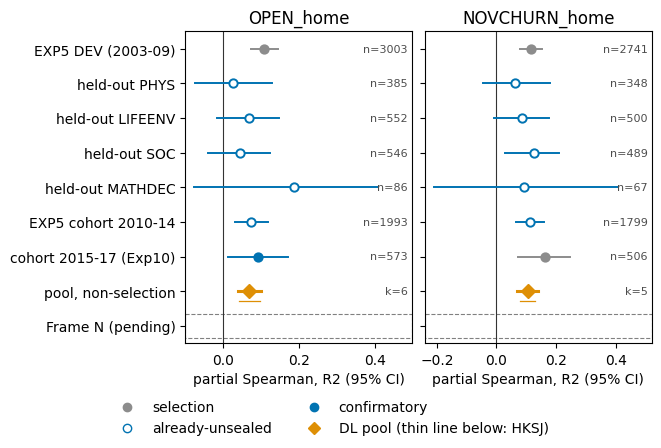

In [16]:
# forest plot — src/figures.py (plain-matplotlib branch, HOUSE = False), reading `syn` instead of results/
PALETTE = ["#0173B2", "#DE8F05", "#029E73"]
ORDER = [("B1_DEV", "EXP5 DEV (2003-09)"), ("B2_PHYS", "held-out PHYS"), ("B2_LIFEENV", "held-out LIFEENV"),
         ("B2_SOC", "held-out SOC"), ("B2_MATHDEC", "held-out MATHDEC"),
         ("B3_EXP5_COHORT_2010_14", "EXP5 cohort 2010-14"), ("B4_COHORT_2015_17", "cohort 2015-17 (Exp10)")]

s = syn
rows_fig = {(r["body"], r["feature"]): r for r in s["rows"]}
fig, axes = plt.subplots(1, 2, figsize=(6.5, 4.4), sharey=False, layout="constrained")
for ax, f in zip(axes, ("OPEN_home", "NOVCHURN_home")):
    labels = []
    y = 0
    for b, lab in ORDER:
        r = rows_fig[(b, f)]
        p = r["R2"]
        st_ = r["status"]
        col = "0.55" if st_.startswith("selection") else PALETTE[0]
        face = col if st_ in ("confirmatory",) or st_.startswith("selection") else "white"
        ax.plot(p["ci"], [y, y], color=col, lw=1.4, zorder=2)
        ax.plot([p["psp"]], [y], marker="o", ms=6, mec=col, mfc=face, mew=1.4, ls="none", zorder=3)
        labels.append(lab)
        ax.annotate(f"n={p['n']}", (1.0, y), xycoords=("axes fraction", "data"), xytext=(-3, 0),
                    textcoords="offset points", ha="right", va="center", fontsize=8, color="0.3")
        y += 1
    pool = s["pools"][f"{f}|R2"]["nonselection"]
    ax.plot(pool["hksj_ci"], [y + 0.28, y + 0.28], color=PALETTE[1], lw=0.9, zorder=2)
    ax.plot(pool["dl_ci"], [y, y], color=PALETTE[1], lw=2.2, zorder=2)
    ax.plot([pool["est"]], [y], marker="D", ms=7, color=PALETTE[1], ls="none", zorder=3)
    labels.append("pool, non-selection")
    ax.annotate(f"k={pool['k']}", (1.0, y), xycoords=("axes fraction", "data"), xytext=(-3, 0),
                textcoords="offset points", ha="right", va="center", fontsize=8, color="0.3")
    y += 1
    ax.axhspan(y - 0.35, y + 0.35, fill=False, ls="--", lw=0.8, ec="0.5")
    labels.append("Frame N (pending)")
    ax.axvline(0, color="0.2", lw=0.8, zorder=1)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels if f == "OPEN_home" else [])
    lo, hi = ax.get_xlim()
    ax.set_xlim(lo, hi + 0.12 * (hi - lo))
    ax.set_ylim(len(labels) - 0.5, -0.5)
    ax.set_xlabel("partial Spearman, R2 (95% CI)")
    ax.set_title(f)
handles = [Line2D([], [], marker="o", color="0.55", mfc="0.55", ls="none", label="selection"),
           Line2D([], [], marker="o", color=PALETTE[0], mfc="white", ls="none", label="already-unsealed"),
           Line2D([], [], marker="o", color=PALETTE[0], mfc=PALETTE[0], ls="none", label="confirmatory"),
           Line2D([], [], marker="D", color=PALETTE[1], ls="none", label="DL pool (thin line below: HKSJ)")]
fig.legend(handles=handles, loc="outside lower center", ncol=2, frameon=False)
fig.savefig(WS / "evidence_forest.png", dpi=150)
plt.show()

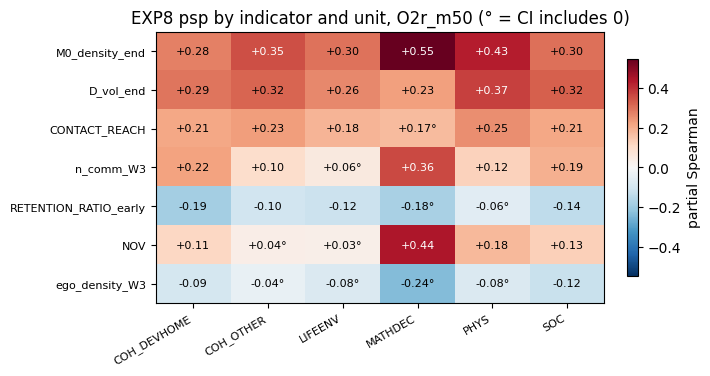

In [17]:
# EXP8 per-group table (results/per_group_table.csv): psp of each indicator in each unit (field group / cohort split)
import collections
units = sorted({r["unit"] for r in pg})
inds = list(dict.fromkeys(r["indicator"] for r in pg))
cell = {(r["indicator"], r["unit"]): r for r in pg}
fig, ax = plt.subplots(figsize=(7, 0.35 * len(inds) + 1.2), layout="constrained")
mat = np.array([[float(cell[(i, u)]["psp"]) if (i, u) in cell else np.nan for u in units] for i in inds])
lim = np.nanmax(np.abs(mat))
im = ax.imshow(mat, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
for yi, i in enumerate(inds):
    for xi, u in enumerate(units):
        if (i, u) in cell:
            r = cell[(i, u)]
            ax.text(xi, yi, f"{float(r['psp']):+.2f}{'' if r['ci_includes_0'] == 'False' else '°'}", ha="center",
                    va="center", fontsize=8, color="white" if abs(float(r["psp"])) > 0.6 * lim else "black")
ax.set_xticks(range(len(units)), units, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(inds)), inds, fontsize=8)
ax.set_title("EXP8 psp by indicator and unit, O2r_m50 (° = CI includes 0)")
fig.colorbar(im, ax=ax, shrink=0.8, label="partial Spearman")
plt.show()